## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [3]:
#количество пропусков в каждом столбце
data.isnull().sum()

Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64

Ответ:\
Пропущенные значения есть.

In [4]:
#удаление строк с пропущенными значениями
data_new = data.dropna()

In [5]:
data_new.dtypes

Species                 object
Island                  object
Clutch Completion       object
Date Egg                 int64
Culmen Length (mm)     float64
Culmen Depth (mm)      float64
Flipper Length (mm)    float64
Body Mass (g)          float64
Sex                     object
Delta 15 N (o/oo)      float64
Delta 13 C (o/oo)      float64
dtype: object

Ответ:\
В наборе данных есть категориальные признаки. 

In [6]:
data_dum = pd.get_dummies(data_new, drop_first=True, dtype=float)
data_dum

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Species_Chinstrap,Species_Gentoo,Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,1.0,0.0,1.0,0.0,1.0,1.0,0.0
2,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,1.0,0.0,1.0,0.0,1.0,1.0,0.0
4,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,382,47.6,18.3,195.0,3850.0,8.83502,-24.65859,1.0,0.0,1.0,0.0,1.0,1.0,0.0
340,382,39.7,18.4,190.0,3900.0,9.29808,-25.23453,0.0,0.0,0.0,1.0,1.0,0.0,1.0
341,16,38.6,17.2,199.0,3750.0,8.77322,-26.48973,0.0,0.0,0.0,0.0,1.0,1.0,0.0
342,392,46.6,14.2,210.0,4850.0,8.38289,-26.86352,0.0,1.0,0.0,0.0,1.0,1.0,0.0


Ответ:\
Самый оптимальный способ закодировать категориальные признаки - это применение one-hot encoding. За счет создания фиктивных переменных категориальные признаки будут представлены вещественными числами, с которыми могут работать любые модели. Кроме того, с числовыми признаками можно выполнять различные арифметические операции. В данном случае категориальных признаков не слишком много, поэтому от "проклятия размерности" датасет не пострадает. В иных случаях стоило бы применить другие способы кодировки.

Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [7]:
data_new.head()

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971


In [8]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[["Chinstrap", "Gentoo", "Adelie"]]) #категории в порядке кодировки
data_enc = enc.fit_transform(data_new[["Species"]]) #возвращает массив
y = data_enc #целевая переменная (вид пингвина)
y

array([[0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [2.],
       [1.],
       [1.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [2.],
       [1.],
       [1.],
       [2.],
       [2.],
       [2.],
       [1.],
       [0.],
       [0.],
       [2.],
       [0.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [1.],
       [0.],
       [2.],
       [0.],
       [1.],
       [1.],
       [1.],
       [2.],
       [2.],
       [1.],
       [2.],
       [0.],
       [2.],
       [1.],
       [1.],
       [2.],
       [2.],
       [0.],
       [2.],
       [0.],
       [0.],
       [1.],
       [0.],
       [2.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [2.],
       [1.],
       [1.],
       [1.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],

Источники:
1) [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html)
2) [Пример использования OrdinalEncoder](https://www.pythonprog.com/sklearn-preprocessing-ordinalencoder/#Use_Cases)

In [9]:
X = data_dum[data_dum.columns.drop(["Species_Chinstrap", "Species_Gentoo"])]
X.head() #признаки

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,1.0,0.0,1.0,0.0,1.0
1,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,1.0,0.0,1.0,1.0,0.0
2,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,0.0,0.0,1.0,1.0,0.0
3,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,1.0,0.0,1.0,1.0,0.0
4,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,0.0,0.0,1.0,1.0,0.0


**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [10]:
from sklearn.model_selection import train_test_split

#np.random.seed(0)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.3, stratify=y)

Ответ:\
Параметр stratify обеспечивает одинаковое соотношение подгрупп (классов) целевой переменной в обучающей и тестовой выборках, что особенно полезно, если данные несбалансированны по группам.

Источники:
1) [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
2) [Разница между np.random.seed() и параметром random_state](https://limitlessdatascience.wordpress.com/2019/02/18/use-of-numpy-random-seed-and-random_state-in-train_test-split-function/)
3) [Параметр stratify](https://sky.pro/media/kak-razdelit-dannye-na-obuchayushhuyu-i-testovuyu-vyborki/)

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

#отбор признаков для обучения
X_train_2 = X_train[["Flipper Length (mm)", "Body Mass (g)"]] 
X_test_2 = X_test[["Flipper Length (mm)", "Body Mass (g)"]]

#масштабирование признаков
scaler = StandardScaler()
X_train_2_sc = scaler.fit_transform(X_train_2.values)
X_test_2_sc = scaler.transform(X_test_2.values)

NN = [1, 3, 5, 10, 15, 25] #количество соседей
list_of_clf = []
print(f'NN\tTrain\tTest')

for number in NN:
    clf = KNeighborsClassifier(n_neighbors=number, p=2, n_jobs=10) #p=2 - евклидова метрика
    clf.fit(X_train_2_sc, np.ravel(y_train))
    list_of_clf.append(clf)
    
    y_predicted_train = clf.predict(X_train_2_sc)
    train_acc = np.round(np.mean(np.ravel(y_train) == y_predicted_train), 2)

    y_predicted_test = clf.predict(X_test_2_sc)
    test_acc = np.round(np.mean(np.ravel(y_test) == y_predicted_test), 2)
    
    print(f'{number}\t{train_acc}\t{test_acc}')

NN	Train	Test
1	0.98	0.78
3	0.88	0.73
5	0.87	0.77
10	0.85	0.78
15	0.84	0.78
25	0.8	0.82


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [23]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB 640.0 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.4 MB 907.3 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.4 MB 1.6 MB/s eta 0:00:01
   ---------- ----------------------------- 0.3/1.4 MB 2.0 MB/s eta 0:00:01
   -------------------- ------------------- 0.7/1.4 MB 3.2 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.4 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 14.9 MB/s eta 0:00:01
   -- ------------------------------------- 0.8/11.1 MB 10.5 MB/s eta 0:00:01
   ---- ----------------------------------- 1.1/11.1 MB 10.2 MB/s eta 0:00:01
   ---- -------

  You can safely remove it manually.


Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [12]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

In [13]:
from itertools import product

combinations = list(product([0, 1], [0, 1, 2]))

for combination in combinations:
    print(combination)

(0, 0)
(0, 1)
(0, 2)
(1, 0)
(1, 1)
(1, 2)


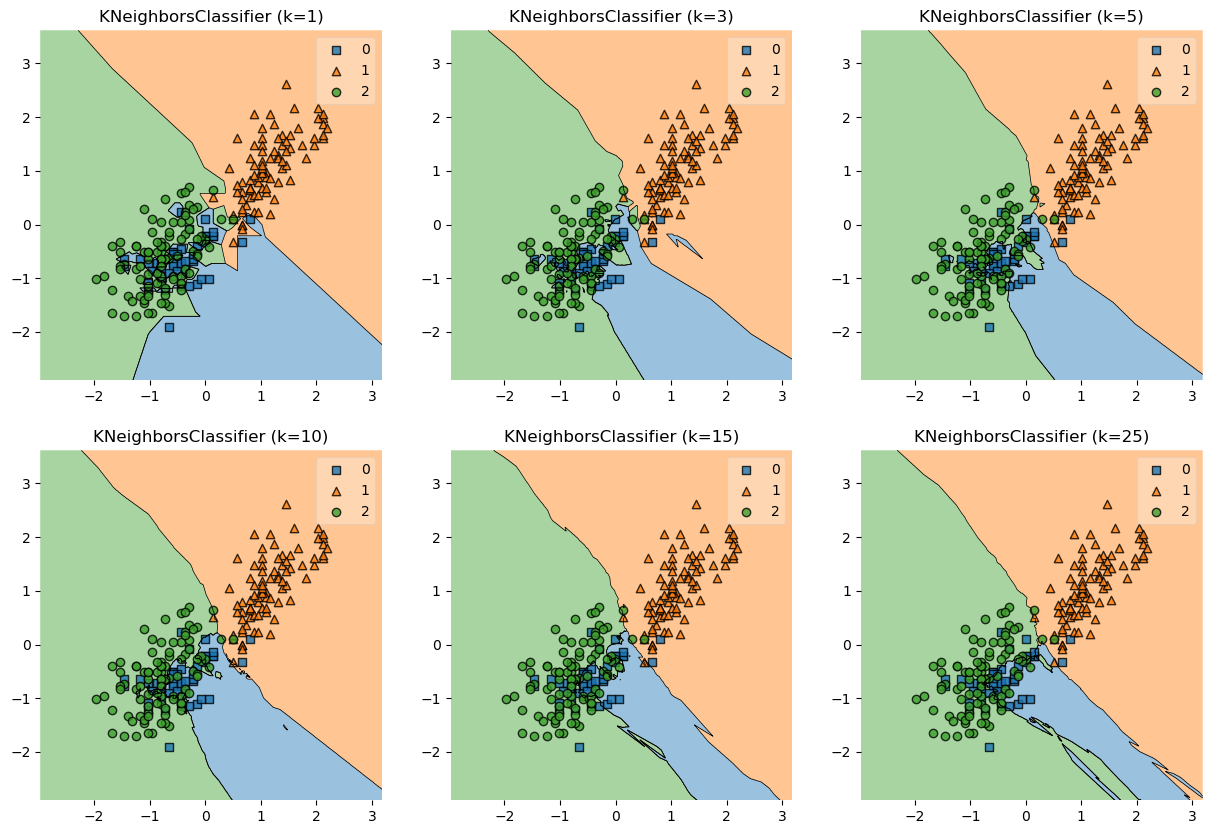

In [14]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
from itertools import product

gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize=(15, 10))

labels = ['KNeighborsClassifier (k=1)', 'KNeighborsClassifier (k=3)', 'KNeighborsClassifier (k=5)', 
          'KNeighborsClassifier (k=10)', 'KNeighborsClassifier (k=15)', 'KNeighborsClassifier (k=25)']

for clf, lab, grd in zip(list_of_clf, labels, product([0, 1], [0, 1, 2])):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=X_train_2_sc, y=np.ravel(y_train.astype(np.int_)), clf=clf, legend=1)
    plt.title(lab)
    
plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Ответ:\
Для обучающей выборки оптимальное число k = 1, для тестовой - 25. Оптимальное число k для модели должно показывать высокие результаты как на обучающей выборке, так и на тестовой, а также значения accuracy не должны сильно отличаться. На мой взгляд, из обученных в задании 1.3 классификаторов можно выбрать классификатор с k = 25, так как модель будет иметь высокое качество (> 0.8), а разница между показателями accuracy на тренировочной и тестовой выборках составляют всего 0.02, что говорит о том, что модель хорошо обучена и хорошо обобщается на новые данные.\
О переобучении модели явно говорят показатели с k = 1, 3 и 5, т.к. на обучающей выборке качество очень высокое и очень сильно отличается с качеством модели на тестовой (разница составляет 0.2, 0.15 и 0.1 соответственно), а также на графиках, полученных в задании 1.5 видно, что для объектов, находящихся в центре, классификатор делает более ломаные границы, стараясь под них подстроиться (особенно это заметно на самом первом графике, где для каждого объекта в качестве ближайшего выбирается он сам).

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

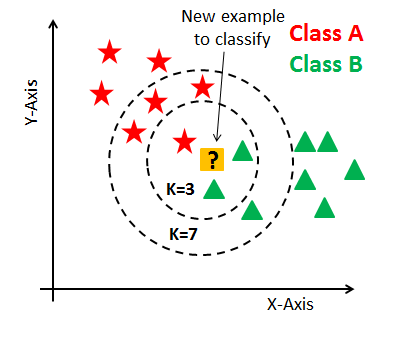

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [15]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        self.X_test = X_test

        list_of_y_predicted = []
        for x in self.X_test:
            list_of_p = np.array([self.count_distance(x, x_train) for x_train in self.X_train]) #массив с расстояниями
            X_nearest_neighbors = np.argsort(list_of_p) #индексы объектов, отсортированных по возрастанию расстояния до нового объекта
            k_nearest_neighbors = X_nearest_neighbors[:self.k] #отбор k ближайших соседей
            y_nearest_neighbors = self.y_train[k_nearest_neighbors]

            counts = Counter(y_nearest_neighbors)
            y_predicted = counts.most_common(1)[0][0]
            list_of_y_predicted.append(y_predicted)
            
        return np.array(list_of_y_predicted)

    def count_distance(self, x, y):
        #x - новый объект
        #y - объект из выборки
        return np.linalg.norm(y - x) #вычисление расстояния с помощью евклидовой метрики

In [16]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [17]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [31]:
#масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

NN = [1, 3, 5, 10, 15, 25] #количество соседей
res = []

for number in NN:
    knn = KNN(number) 
    knn.fit(X_train_scaled, np.ravel(y_train))

    y_predicted_test = knn.predict(X_test_scaled)
    test_acc = np.mean(np.ravel(y_test) == y_predicted_test)
    res.append((number, test_acc))

max_test_acc = max(res, key=lambda x: x[1])
print(f'Лучшее k: {max_test_acc[0]} с точностью {np.round(max_test_acc[1], 4)} на test.')

Лучшее k: 3 с точностью 0.9898 на test.


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [2]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [3]:
#количество пропусков в каждом столбце
data.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Ответ:\
Пропущенных значений нет, есть бессмысленный столбец "Unnamed: 0".

In [4]:
#удаление столбца "Unnamed: 0"
data = data[data.columns.drop("Unnamed: 0")]
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [5]:
corr_matrix = pd.DataFrame(data.corr(numeric_only = True)["price"])
corr_matrix

,price
carat,0.921591
depth,-0.010647
table,0.127134
price,1.000000
x,0.884435
y,0.865421
z,0.861249


Ответ:\
Наибольшую корреляцию с целевой переменной "price" имеют признаки "carat" (вес бриллианта) и "x", "y", "z" (длина, ширина, глубина бриллианта).

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [6]:
data = pd.get_dummies(data, drop_first=True, dtype=float)
data.head()

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [9]:
from sklearn.model_selection import train_test_split
X = data[data.columns.drop("price")]
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.3)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [39]:
from sklearn.preprocessing import StandardScaler

#масштабирование признаков
scaler = StandardScaler()
X_train_float_feat_scaled = pd.DataFrame(data=scaler.fit_transform(X_train.iloc[:, :6].values), columns=X_train.iloc[:, :6].columns, index=X_train.index)
X_test_float_feat_scaled = pd.DataFrame(data=scaler.transform(X_test.iloc[:, :6].values), columns=X_test.iloc[:, :6].columns, index=X_test.index)
X_train_scaled = X_train_float_feat_scaled.join(X_train.iloc[:, 6:])
X_test_scaled = X_test_float_feat_scaled.join(X_test.iloc[:, 6:])
X_train_scaled.head()

,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
16259,0.445813,0.170523,-0.201734,0.630510,0.540663,0.605461,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
24005,1.562356,0.588814,-0.649638,1.503049,1.397771,1.519486,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12211,0.740749,0.937389,2.485693,0.799676,0.687843,0.858576,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37918,-0.818197,-0.805489,-0.201734,-0.838559,-0.775299,-0.871040,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
181,-0.544328,-0.178053,-0.201734,-0.437904,-0.411678,-0.435121,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Ответ:\
Масштабирование признаков позволяет судить о его важности (силе влияния) на целевую переменную. До этого все признаки измерялись в разных единицах и не могли быть сравнимы между собой.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
r2 = r2_score(y_train, lr.predict(X_train_scaled))

mse_train = mean_squared_error(y_train, lr.predict(X_train_scaled))
mse_test = mean_squared_error(y_test, lr.predict(X_test_scaled))

print(f'R2 score in the training sample is: {np.round(r2, 3)}')
print(f'Mean Square Error in the training sample is: {np.round(mse_train, 3)}')
print(f'Mean Square Error in the testing sample is: {np.round(mse_test, 3)}')

R2 score in the training sample is: 0.919
Mean Square Error in the training sample is: 1284661.862
Mean Square Error in the testing sample is: 1259159.114


Ответ:\
Модель описывает около 92% разброса (дисперсии) цены на бриллианты в тренировочной выборке, что говорит о том, что предикторы очень хорошо описывают имеющуюся зависимость.

**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [74]:
coefficients = lr.coef_
print(coefficients)

[ 5.27811998e+03 -9.42669361e+01 -6.56183723e+01 -1.05002476e+03
 -2.64737971e+00 -4.05686230e+01  5.41639869e+02  7.95786817e+02
  7.21797535e+02  6.98433173e+02 -1.80617972e+02 -2.36924694e+02
 -4.50558533e+02 -9.43618044e+02 -1.42880833e+03 -2.34337515e+03
  5.33355507e+03  3.67037809e+03  2.70186810e+03  4.59244827e+03
  4.27255738e+03  5.02155858e+03  4.95459850e+03]


In [75]:
columns = np.array(X_train_scaled.columns)
columns

array(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Good', 'cut_Ideal',
       'cut_Premium', 'cut_Very Good', 'color_E', 'color_F', 'color_G',
       'color_H', 'color_I', 'color_J', 'clarity_IF', 'clarity_SI1',
       'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1',
       'clarity_VVS2'], dtype=object)

In [79]:
for coef, col in zip(coefficients[0:6], columns[0:6]):
    if np.abs(coef) > 100:
        print(coef, col)

5278.119983938968 carat
-1050.024759755721 x


Ответ:\
Очень высокие оценки коэффициентов имеют вещественные переменные "carat" (вес бриллианта) и "x" (длина бриллианта).

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [84]:
coefficients

array([ 5.27811998e+03, -9.42669361e+01, -6.56183723e+01, -1.05002476e+03,
       -2.64737971e+00, -4.05686230e+01,  5.41639869e+02,  7.95786817e+02,
        7.21797535e+02,  6.98433173e+02, -1.80617972e+02, -2.36924694e+02,
       -4.50558533e+02, -9.43618044e+02, -1.42880833e+03, -2.34337515e+03,
        5.33355507e+03,  3.67037809e+03,  2.70186810e+03,  4.59244827e+03,
        4.27255738e+03,  5.02155858e+03,  4.95459850e+03])

In [80]:
from sklearn.linear_model import Lasso, Ridge
lasso = Lasso(10.0).fit(X_train_scaled, y_train) 
print("Lasso")
print(lasso.coef_)

ridge = Ridge(10.0).fit(X_train_scaled, y_train)
print("\nRidge")
print(ridge.coef_)

Lasso
[ 4.71743050e+03 -1.53897630e+02 -1.14359498e+02 -6.34665961e+02
 -0.00000000e+00 -2.38637594e+01 -0.00000000e+00  1.57773311e+02
  6.49642121e+01  8.29123605e+01  2.89245109e+00  0.00000000e+00
 -1.11417566e+02 -5.94797373e+02 -9.89237948e+02 -1.78579096e+03
  1.36634737e+03  7.08619218e+01 -7.35084934e+02  9.09413824e+02
  6.55593919e+02  1.24299124e+03  1.24071029e+03]

Ridge
[ 5.22844129e+03 -9.72441606e+01 -6.85479296e+01 -1.01276713e+03
 -1.71800611e+00 -4.16912899e+01  5.64972250e+02  8.23308089e+02
  7.46147154e+02  7.27722546e+02 -1.68557828e+02 -2.23702621e+02
 -4.33182440e+02 -9.26878179e+02 -1.40434915e+03 -2.30843494e+03
  4.76047220e+03  3.14279042e+03  2.18215462e+03  4.05576226e+03
  3.74139226e+03  4.47074534e+03  4.41139173e+03]


Ответ:\
В результате применения Lasso-регрессии веса довольно сильно уменьшились, однако в результате применения Ridge-регрессии изменения совсем незначительные. Посмотрев на веса, полученные в результате применения Lasso-модели, можно увидеть, что некоторые из них обнулились, значит, они были неважными или коррелировали с другими признаками. Таким образом, в исходной модели мультиколлинеарность скорее всего была.

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

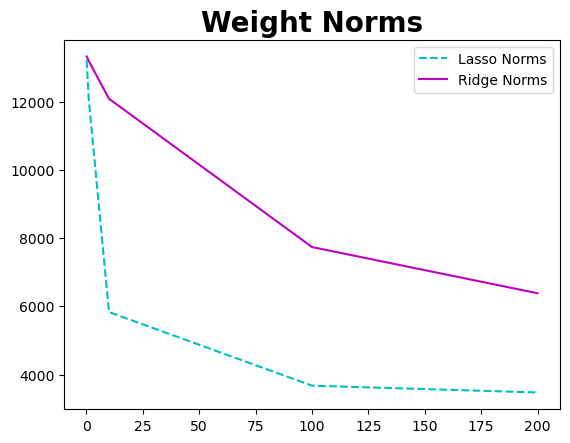

In [89]:
alpha = [0.1, 1, 10, 100, 200]
lasso_norms = []
ridge_norms = []

for a in alpha:
    lasso = Lasso(a).fit(X_train_scaled, y_train) 
    ridge = Ridge(a).fit(X_train_scaled, y_train) 
    lasso_norm = np.linalg.norm(lasso.coef_)
    lasso_norms.append(lasso_norm)
    ridge_norm = np.linalg.norm(ridge.coef_)
    ridge_norms.append(ridge_norm)

plt.figure()
plt.title("Weight Norms", size=20, weight="heavy")
x = alpha
y1 = lasso_norms
y2 = ridge_norms
plt.plot(x, y1, c="c", linestyle="--", label="Lasso Norms") #нанесение 1-ого графика
plt.plot(x, y2, c="m", label="Ridge Norms") #нанесение 2-ого графика
plt.legend()
plt.show()

Ответ:\
Метод Lasso сильнее снижает норму коэффициентов, так как он способен занулять незначимые для модели веса, "выкидывать" их из нее и сохранять только те, которые оказывают значительное влияние на результат. Таким образом Lasso-регрессия предотвращает переобучение модели и снижает риск мультиколлинеарности.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [109]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, alphas=[0.1, 1, 10, 100, 200], random_state=0).fit(X_train_scaled, y_train)
mean_mse_alpha = []
for mse, alpha in zip(lasso.mse_path_, lasso.alphas_):
    mean_mse_alpha.append((np.round(np.mean(mse), 2), alpha))
min_mse = min(mean_mse_alpha, key=lambda x: x[0])
print(f'Наибольшее качество дает alpha = {min_mse[1]}.')

C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1177271856.726532, tolerance: 48309472.87280813
  model = cd_fast.enet_coordinate_descent_gram(


Наибольшее качество дает alpha = 1.0.


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [102]:
lasso = Lasso(1.0).fit(X_train_scaled, y_train)
print(lasso.coef_)

[ 5219.22347004  -103.13762135   -72.1147423  -1009.83968765
    -0.           -38.51315893   437.82050935   694.91027222
   619.88427512   601.60047184  -127.15409692  -183.44785077
  -392.82799349  -885.21920917 -1360.43955047 -2263.2030689
  4792.95148523  3171.13910035  2206.8162007   4082.07719954
  3770.07330299  4500.32277913  4440.81059919]


In [104]:
for coef, col in zip(lasso.coef_, columns):
    if coef == 0:
        print(coef, col)

-0.0 y


In [106]:
for coef, col in zip(lasso.coef_, columns):
    if np.abs(coef) > 2500:
        print(coef, col)

5219.22347003968 carat
4792.951485229572 clarity_IF
3171.1391003520603 clarity_SI1
4082.0771995429363 clarity_VS1
3770.0733029947423 clarity_VS2
4500.322779129321 clarity_VVS1
4440.810599187433 clarity_VVS2


Ответ:\
Неинформативным оказался признак "y" (ширина бриллианта), а наиболее информативными - "carat" (вес бриллианта) и "clarity" (чистота, прозрачность бриллианта). Вес бриллианта (в каратах) наиболее сильно влияет на его цену, т.к. крупные, тяжелые бриллианты встречаются очень редко, их добыча гораздо сложнее, поэтому и стоимость таких редких объектов будет очень высокой. Чистота бриллианта, в свою очередь, является характеристикой его внешнего вида, на которую тоже всегда обращают внимание: есть ли царапины, трещины в камне и т.п. Ширина бриллианта не сильно влияет на его стоимость вероятно из-за того, что другие характеристики оказываются для покупателей более важными. Кроме того, ширина, как и вес, характеризуют размер камня, а потому вес тоже может дать информацию о ширине.

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [108]:
lasso = Lasso(1.0)
lasso.fit(X_train_scaled, y_train)
mse_test_lasso = mean_squared_error(y_test, lasso.predict(X_test_scaled))
mse_test_lasso

1266198.458052361

Ответ:\
MSE для Lasso - 1266198.46, а для обычной линейной регресии - 1259159.11. Исходя из значений среднеквадратичных ошибок, для предсказаний следует использовать модель обычной линейной регресии, так как ее ошибка меньше. Вероятно, использованный коэффициент регуляризации оказался достаточно сильным и модель исключила признаки, которые на самом деле улучшали предсказание. При проведении кросс-валидации как раз высвечивалось предупреждение о том, что количество итераций (рассматриваемых коэффициентов регуляризации) слишком маленькое, поэтому был подобран не самый оптимальный коэффициент.